# Example

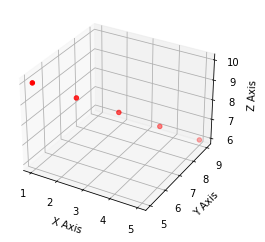

In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x = [1, 2, 3, 4, 5]
y = [5, 6, 7, 8, 9]
z = [10, 9, 8, 7, 6]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x, y, z, c='r', marker='o')

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')

plt.show()


# Implementation

In [49]:
import json

with open('my_project/controllers/my_controller/learnt_policies.json', 'r') as f:
    data = json.load(f)

all_trajectories = []

for policy in data:
    trajectory = [policy["Coordinates"][0]] +  policy["SetPairs"][1:] +[policy["Coordinates"][1]]
    
    all_trajectories.append(trajectory)
    
print(all_trajectories)

[[[17, 5], [5, 16], [5, 8], [2, 0], [17, 1], [10, 2], [8, 11], [13, 0], [15, 16], [14, 15], [1, 3], [5, 13]], [[8, 10], [11, 6], [2, 17], [1, 0], [5, 8], [3, 8], [18, 2], [11, 18], [17, 1], [18, 9], [10, 8], [8, 11]], [[8, 7], [16, 11], [2, 3], [9, 3], [16, 1], [7, 8], [12, 0], [13, 2], [5, 6], [12, 16], [12, 16], [9, 7]], [[16, 14], [13, 10], [17, 16], [15, 10], [15, 4], [9, 7], [10, 5], [11, 17], [15, 0], [6, 12], [8, 9], [13, 14]], [[12, 8], [7, 4], [14, 4], [0, 10], [6, 1], [18, 10], [15, 7], [3, 16], [12, 1], [11, 11], [11, 17], [14, 17]], [[2, 11], [17, 13], [3, 9], [18, 18], [6, 5], [4, 7], [6, 3], [9, 3], [2, 5], [0, 9], [12, 3], [9, 9]], [[14, 14], [15, 12], [6, 18], [8, 17], [6, 0], [2, 14], [13, 18], [13, 8], [6, 14], [16, 7], [8, 10], [6, 8]], [[18, 3], [10, 15], [9, 0], [16, 10], [10, 4], [2, 16], [9, 18], [12, 15], [8, 10], [1, 13], [11, 7], [14, 18]], [[14, 6], [13, 8], [2, 2], [3, 17], [12, 0], [1, 1], [10, 13], [10, 10], [15, 8], [6, 3], [14, 6], [12, 18]], [[8, 8], [1

In [50]:
from minisom import MiniSom
import pickle

with open('my_project/controllers/my_controller/somVisual.p', 'rb') as infile:
    somVisual = pickle.load(infile)
    
weights_som = somVisual.get_weights()

def get_coordinate(input):
    som_winner =weights_som[input[0], input[1]]
    return som_winner

all_coordinates= []
for trajectory in all_trajectories:
    new_coordinates=[]
    for coordinate in trajectory:
        new_coord=get_coordinate(coordinate)
        new_coord=list(new_coord)
        new_coordinates.append(new_coord) 
    all_coordinates.append(new_coordinates)
    
#print(all_coordinates)

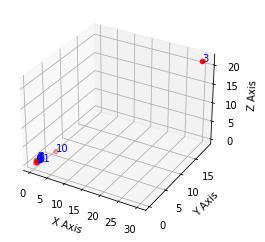

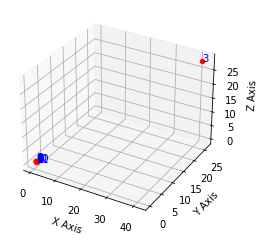

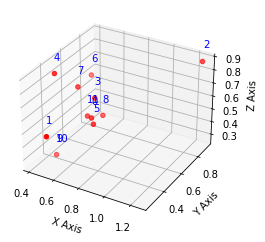

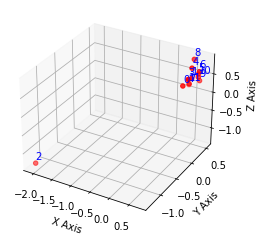

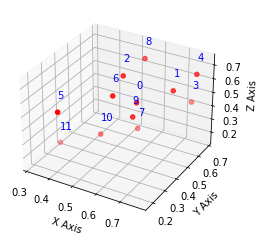

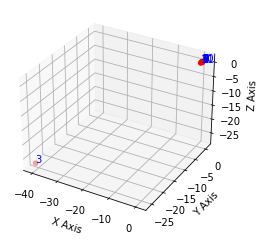

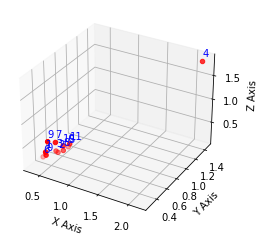

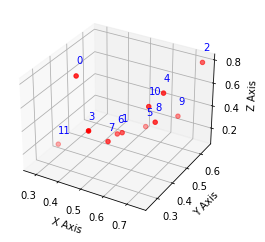

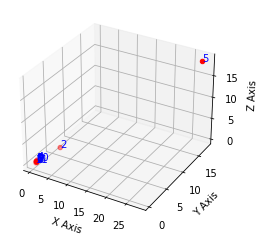

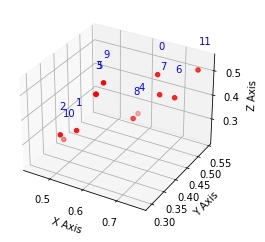

In [51]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

for i in range(len(all_coordinates)-1):
    trajectory_to_plot= all_coordinates[i]

    x = []
    y = []
    z = []

    for coordinate in trajectory_to_plot:
        x.append(coordinate[0])
        y.append(coordinate[1])
        z.append(coordinate[2])

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(x, y, z, c='r', marker='o')
    
    for index, (x_coord, y_coord, z_coord) in enumerate(trajectory_to_plot):
        ax.text(x_coord, y_coord, z_coord + 0.1, str(index), color='blue')  # Adjust z + 0.1 to position text above the point


    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis')

    plt.show()